In [2]:
import pandas as pd
import seaborn as sns
import glob
import json

In [2]:
fin_file_paths = glob.glob("../data/fin_Latn/*token_counts.jsonl")
swe_file_paths = glob.glob("../data/swe_Latn/*token_counts.jsonl")

In [3]:
def read_data(file_paths):
    d = []
    for f_p in file_paths:
        with open(f_p) as f:
            for l in f:
                json_line = json.loads(l)
                d.append(json_line)
    return d

fin_d = read_data(fin_file_paths)
swe_d = read_data(swe_file_paths)

In [4]:
fin_df = pd.DataFrame(data=fin_d)

In [5]:
fin_df = fin_df.set_index('id')


In [5]:
def assign_bin(t):
    if 1000 <= t < 3000:
        return "1k-3k"
    elif 3000 <= t < 10000:
        return "3k-10k"
    elif 10000 <= t < 128000:
        return ">10k-128k"
    elif t >= 128000:
        return ">=128000"
    else:
        return "<1k"

In [7]:
fin_df["bin"] = fin_df["tokens"].apply(assign_bin)
fin_df['bin'].value_counts()

bin
<1k       3012173
1k-3k     1746424
3k-10k     539098
>=10k       54003
Name: count, dtype: int64

<Axes: xlabel='bin', ylabel='Count'>

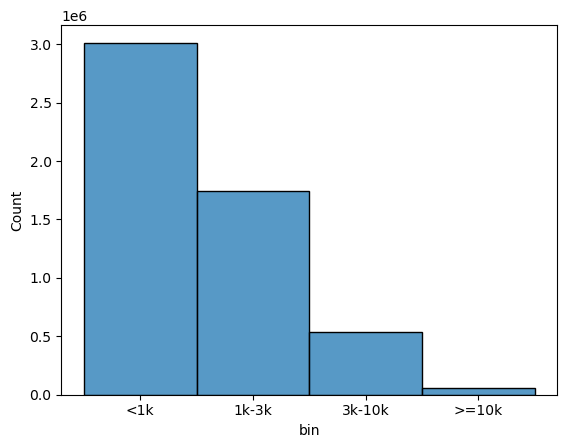

In [8]:
sns.histplot(data=fin_df, x="bin")

In [9]:
seed = 66
bins_to_use = ["1k-3k", "3k-10k", ">=10k"]
# Define ratios per bin (must sum to 1.0)
n_per_bin = {
    "1k-3k": 5000,
    "3k-10k": 45000,
    ">=10k": 50000,
}


In [10]:
parts = []
for b, n in n_per_bin.items():
    g = fin_df[fin_df["bin"] == b]
    parts.append(g.sample(n=n, random_state=seed))

fin_sampled = pd.concat(parts)
fin_sampled = fin_sampled.sample(frac=1, random_state=seed).reset_index()

In [11]:
fin_sampled

,id,tokens,chars,bin
0,2600a9784f5dedbf2a4a4eb632fa3256,4157,31772,3k-10k
1,47407d0cfde203fe9a6b97c5dd71c37c,10785,79749,>=10k
2,4e1952dbecb068570802b6847a8867da,12500,90157,>=10k
3,59c29c9a3687ffb2558b6517b418a480,6244,44834,3k-10k
4,36e275a5c4b1e51c508867aa780d55a6,3463,20357,3k-10k
...,...,...,...,...
99995,3f19daa48b252c816e80e7d4d869aac7,34534,262616,>=10k
99996,85c1701606535f0e5f9daf994da77d5e,10600,85695,>=10k
99997,2f7d83b1b8e6df7a10607548839e6e3b,5422,39198,3k-10k
99998,4f57b4409c45248c00a5b66b7835b9bb,5889,40892,3k-10k


In [12]:
fin_sampled.describe()

,tokens,chars
count,100000.000000,1.000000e+05
mean,10814.617590,7.630840e+04
std,11017.394093,7.768348e+04
min,1000.000000,5.840000e+03
25%,4951.000000,3.492075e+04
50%,9998.500000,6.640350e+04
75%,12588.000000,8.878600e+04
max,760995.000000,4.601648e+06


In [13]:
fin_sampled.to_json("../data/fin_Latn/fin_Latn_corpus_ids.jsonl", orient="records", lines=True, force_ascii=False)

In [14]:
del fin_sampled, fin_df, fin_d

In [15]:
swe_df = pd.DataFrame(data=swe_d)
swe_df = swe_df.set_index('id')
swe_df["bin"] = swe_df["tokens"].apply(assign_bin)
swe_df['bin'].value_counts()

bin
<1k       3533602
1k-3k     2218169
3k-10k     618842
>=10k       60826
Name: count, dtype: int64

<Axes: xlabel='bin', ylabel='Count'>

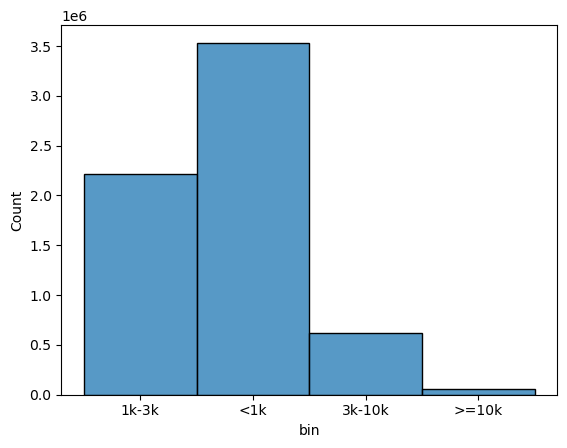

In [16]:
sns.histplot(data=swe_df, x="bin")

In [17]:
parts = []
for b, n in n_per_bin.items():
    g = swe_df[swe_df["bin"] == b]
    parts.append(g.sample(n=n, random_state=seed))

swe_sampled = pd.concat(parts)
swe_sampled = swe_sampled.sample(frac=1, random_state=seed).reset_index()

In [18]:
swe_sampled.to_json("../data/swe_Latn/swe_Latn_corpus_ids.jsonl", orient="records", lines=True, force_ascii=False)

In [6]:
swe_df["bin"] = swe_df["tokens"].apply(assign_bin)
swe_df['bin'].value_counts()

bin
>10k-128k    49898
3k-10k       45000
1k-3k         5000
>=128000       102
Name: count, dtype: int64

In [3]:
def read_data(f_p):
    d=[]
    with open(f_p) as f:
        for l in f:
            json_line = json.loads(l)
            d.append(json_line)
    return d

swe_path = "../data/swe_Latn/swe_Latn_corpus_ids.jsonl"
fin_path = "../data/fin_Latn/fin_Latn_corpus_ids.jsonl"
fin_d = read_data(fin_path)
swe_d = read_data(swe_path)


In [4]:
swe_df = pd.DataFrame(data=swe_d)
fin_df = pd.DataFrame(data=fin_d)

In [7]:
fin_df["bin"] = fin_df["tokens"].apply(assign_bin)
fin_df['bin'].value_counts()

bin
>10k-128k    49912
3k-10k       45000
1k-3k         5000
>=128000        88
Name: count, dtype: int64

In [17]:
swe_stats = swe_df.describe()
fin_stats = fin_df.describe()

In [18]:
swe_stats.loc['total'] = {'tokens': swe_df['tokens'].sum(), 'chars': swe_df['chars'].sum()}
fin_stats.loc['total'] = {'tokens': fin_df['tokens'].sum(), 'chars': fin_df['chars'].sum()}

In [21]:
swe_stats.to_csv("../data/swe_Latn/swe_Latn_corpus_stats.csv")
fin_stats.to_csv("../data/fin_Latn/fin_Latn_corpus_stats.csv")